## SGD with Momentum

So a neural network have generally a non-convex optimization landscape (i.e multiple minimas, saddle points, noisy gradient etc, exists in the contour)
Problems with non-convex optimization problems:

- Local Minima: Points where the slope is zero, but they aren’t the lowest point.
- Saddle Points: Flat regions where the slope is zero in some directions but not in others, slowing down SGD.
- High Curvature: Regions with steep gradients in one direction, causing large steps that may overshoot the minimum.

Momentum solves these problems 

_what is intuition behind momentum?_:   
Like in physics, imagine a ball going downwards in a bowl, it'll gain momentum every second till it reaches the bottom.   
Similarily here, consider our gradient have to move from A --> B (minima) it'll go with the flow of graidents, if gradients in a direction allows loss to be decreased, the gradient will gain momentum and move faster towards that direction 

Update rule for SGD:

$$
W_{t+1} =  W_t - \eta \nabla W_t
$$

Update rule for SGD with Momentum

$$
W_{t+1} = W_t - V_t
$$

Where, $V_t$ is EWMA of $W_t$
$$
V_t = \beta V_{t-1} + \eta \nabla W_t
$$

Where, $\beta$ is called "Decaying factor". For multiple gradients of $W_1, W_2, W_3...$ initial graidents will get less importance and newer gradients will get exponentially more importance 

Hence the final formula becomes:
$$
W_{t+1} = W_t - (\beta V_{t-1} + \eta \nabla W_t)
$$

- $\beta V_{t-1}$ acts as velocity, higher the velocity, bigger the steps of updation (hence faster movement of weights in loss contour)

Note - _Value of $\beta$ should not be 0 or 1
- Should not be Zero
    - Because then SGD with momentum will become simple SGD only

- Should not be One
    - Because then all the previous gradients will get equal importance. Hence
        - 1. No Forgetting old gradients: Older gradients may be irrelevant but still affects current steps when moving towards minima
        - 2. Updates will be so large due to accumulation of all gradients: Oscilation and Divergence will be observed
        - 3. $\beta < 1$ acts as "Velocity with Friction", if there is no friction in the ball and bowl example, the ball will never stop moving at minima. Similar thing happens with weights, weights will not stop at minima 

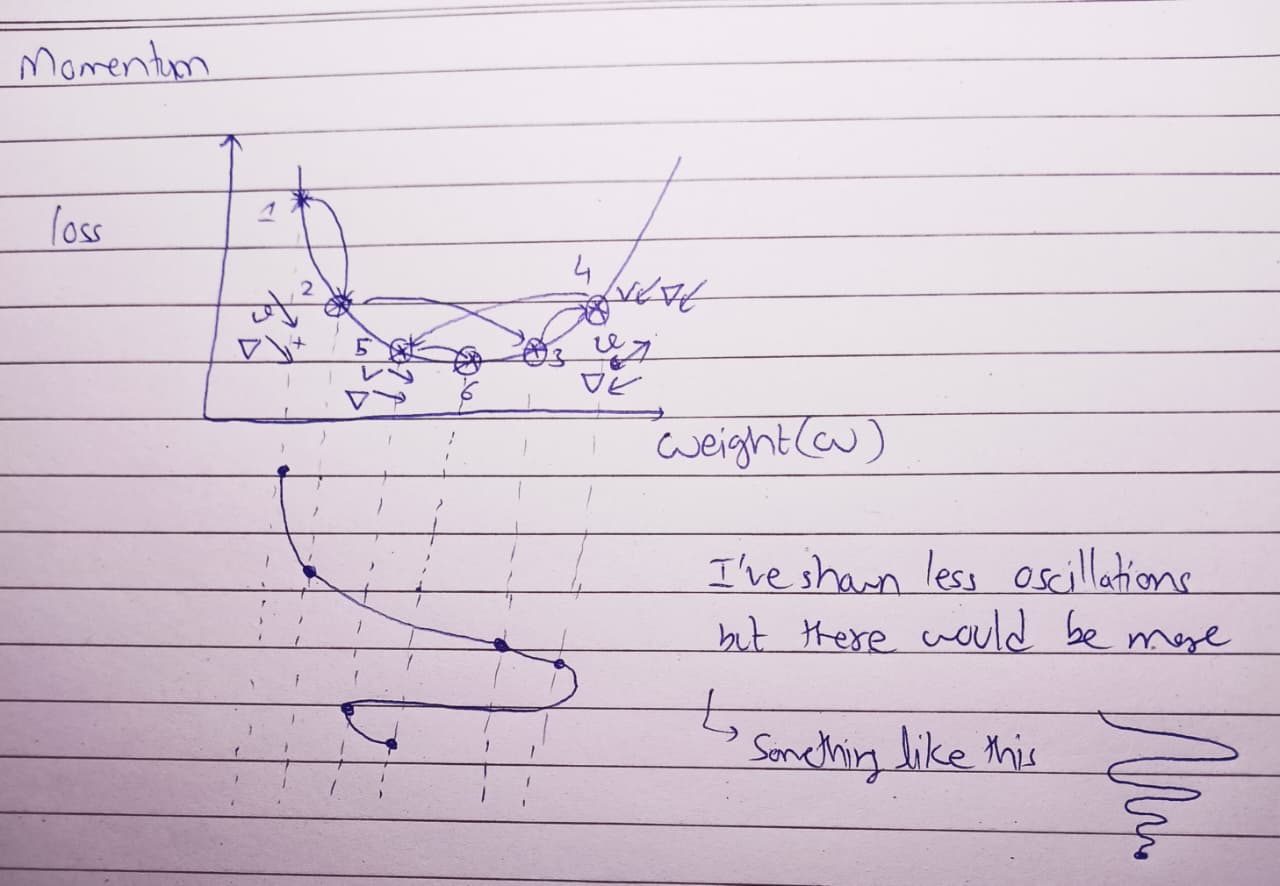

### Advantages:
- It has velocity, hence can escape local minimas and saddle points
- Faster Convergence: Accelerates in directions where gradients are consistent

### Disadvantages: 
- It havs velocity, hence it may waste some time oscillating around minima before stopping